In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Optional, Tuple

In [2]:
df_train = pd.read_parquet('../data/01_raw/df_train.parquet')
df_test = pd.read_parquet('../data/01_raw/df_test.parquet')

### PSI

In [3]:
def psi(
    reference_df: pd.DataFrame,
    monitored_df: pd.DataFrame,
    bins: Optional[int] = None
) -> float:
    """
    Calculate the Population Stability Index (PSI) between two pandas DataFrames
    that contain exactly ONE column.
    """

    # Extract the single column as numpy arrays
    reference = reference_df.iloc[:, 0].dropna().to_numpy()
    monitored = monitored_df.iloc[:, 0].dropna().to_numpy()

    full_dataset = np.concatenate((reference, monitored))

    # Use Doane's formula if bins not provided
    if bins is None:
        _, bin_edges = np.histogram(full_dataset, bins="doane")
    else:
        bin_edges = np.linspace(
            min(reference.min(), monitored.min()),
            max(reference.max(), monitored.max()),
            bins + 1
        )

    reference_hist, _ = np.histogram(reference, bins=bin_edges)
    monitored_hist, _ = np.histogram(monitored, bins=bin_edges)

    reference_proportions = reference_hist / np.sum(reference_hist)
    monitored_proportions = monitored_hist / np.sum(monitored_hist)

    # Avoid division by zero
    monitored_proportions = np.where(monitored_proportions == 0, 1e-6, monitored_proportions)
    reference_proportions = np.where(reference_proportions == 0, 1e-6, reference_proportions)

    psi_values = (
        (monitored_proportions - reference_proportions)
        * np.log(monitored_proportions / reference_proportions)
    )

    return float(np.sum(psi_values))

In [4]:
window_size = 2000
step_size = 200
feature_col = "GenRPM"

reference_df = df_train[[feature_col]]

psi_values_train = []
timestamps_train = []

for end_idx in range(window_size, len(df_train), step_size):

    monitored_df = df_train[[feature_col]].iloc[end_idx - window_size:end_idx]

    psi_score = psi(reference_df, monitored_df)

    psi_values_train.append(psi_score)
    timestamps_train.append(df_train.iloc[end_idx]["Timestamps"])

psi_train_df = pd.DataFrame({
    "Timestamp": timestamps_train,
    "psi": psi_values_train
})

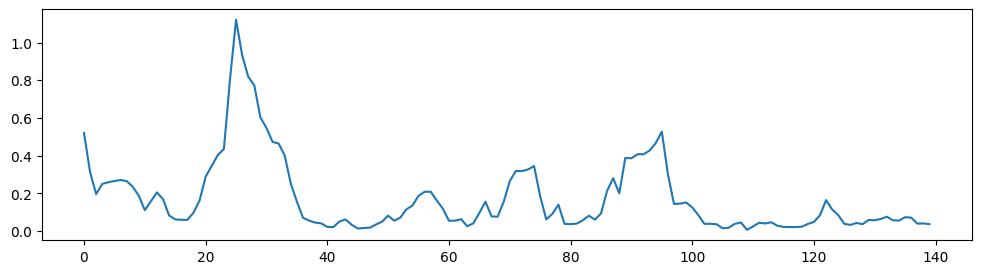

In [5]:
plt.figure(figsize=(12, 3))
plt.plot(psi_train_df['psi'])

In [6]:
window_size = 2000

psi_values_test = []
timestamps_test = []

for end_idx in range(window_size, len(df_test), step_size):

    monitored_df = df_test[[feature_col]].iloc[end_idx - window_size:end_idx]

    psi_score = psi(reference_df, monitored_df)

    psi_values_test.append(psi_score)
    timestamps_test.append(df_test.iloc[end_idx]["Timestamps"])

psi_test_df = pd.DataFrame({
    "Timestamp": timestamps_test,
    "psi": psi_values_test
})


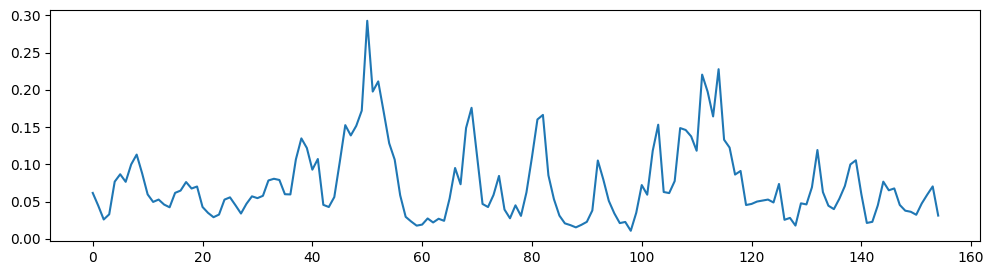

In [7]:
plt.figure(figsize=(12, 3))
plt.plot(psi_test_df['psi'])

Text(0.5, 1.0, 'PSI Distance')

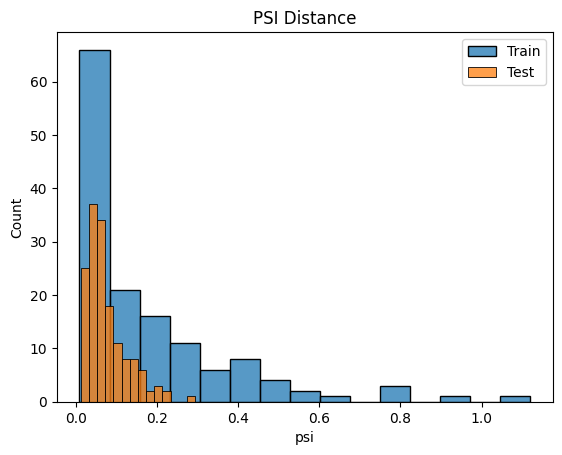

In [8]:
sns.histplot(psi_train_df['psi'], label='Train')
sns.histplot(psi_test_df['psi'], label='Test')
plt.legend()
plt.title('PSI Distance')

### Wasserstein

In [9]:
def wasserstein_distance_1d(
    reference_df: pd.DataFrame,
    monitored_df: pd.DataFrame,
    bins: Optional[int] = None,
) -> float:
    """
    1D Wasserstein distance (Earth Mover's Distance) between two 1-column DataFrames.

    Implemented in a PSI-like way (histogram-based):
      1) build bin edges (Doane if bins is None)
      2) compute histograms -> proportions
      3) compute the 1D EMD via CDF difference:
            W1 ≈ sum_k |CDF_ref(k) - CDF_mon(k)| * bin_width_k

    Notes:
    - This is an approximation using histograms (good for monitoring & fast plots).
    - Bin edges are computed on the combined dataset to cover both ranges.
    """

    reference = reference_df.iloc[:, 0].dropna().to_numpy()
    monitored = monitored_df.iloc[:, 0].dropna().to_numpy()

    if reference.size == 0 or monitored.size == 0:
        raise ValueError("reference_df and monitored_df must contain at least 1 non-null value each.")

    full_dataset = np.concatenate((reference, monitored))

    if bins is None:
        _, bin_edges = np.histogram(full_dataset, bins="doane")
    else:
        bin_edges = np.linspace(
            min(reference.min(), monitored.min()),
            max(reference.max(), monitored.max()),
            bins + 1
        )

    ref_hist, _ = np.histogram(reference, bins=bin_edges)
    mon_hist, _ = np.histogram(monitored, bins=bin_edges)

    ref_p = ref_hist / ref_hist.sum()
    mon_p = mon_hist / mon_hist.sum()

    ref_cdf = np.cumsum(ref_p)
    mon_cdf = np.cumsum(mon_p)

    bin_widths = np.diff(bin_edges)

    w1 = float(np.sum(np.abs(ref_cdf - mon_cdf) * bin_widths))
    return w1

In [10]:
window_size = 2000
step_size = 200
feature_col = "GenRPM"

w_values_train = []
timestamps_train = []

reference_df = df_train[[feature_col]]  # full train as reference

for end_idx in range(window_size, len(df_train), step_size):

    monitored_df = df_train[[feature_col]].iloc[end_idx - window_size:end_idx]

    w_score = wasserstein_distance_1d(reference_df, monitored_df)

    w_values_train.append(w_score)
    timestamps_train.append(df_train.iloc[end_idx]["Timestamps"])

w_train_df = pd.DataFrame({
    "Timestamp": timestamps_train,
    "wasserstein": w_values_train
})

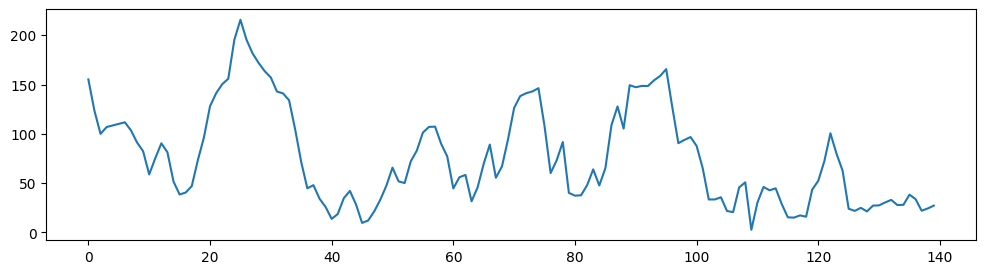

In [11]:
plt.figure(figsize=(12, 3))
plt.plot(w_train_df['wasserstein'])

In [12]:
window_size = 2000
feature_col = "GenRPM"

w_values_test = []
timestamps_test = []

# IMPORTANT: use SAME reference as train
reference_df = df_train[[feature_col]]

for end_idx in range(window_size, len(df_test), step_size):

    monitored_df = df_test[[feature_col]].iloc[end_idx - window_size:end_idx]

    w_score = wasserstein_distance_1d(reference_df, monitored_df)

    w_values_test.append(w_score)
    timestamps_test.append(df_test.iloc[end_idx]["Timestamps"])

w_test_df = pd.DataFrame({
    "Timestamp": timestamps_test,
    "wasserstein": w_values_test
})

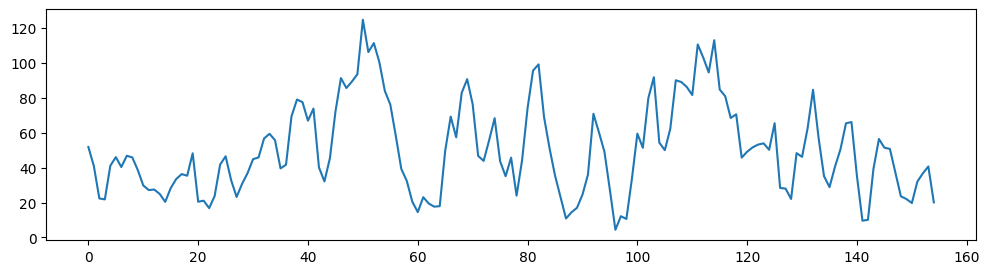

In [13]:
plt.figure(figsize=(12, 3))
plt.plot(w_test_df['wasserstein'])

Text(0.5, 1.0, 'Wasserstein Distance')

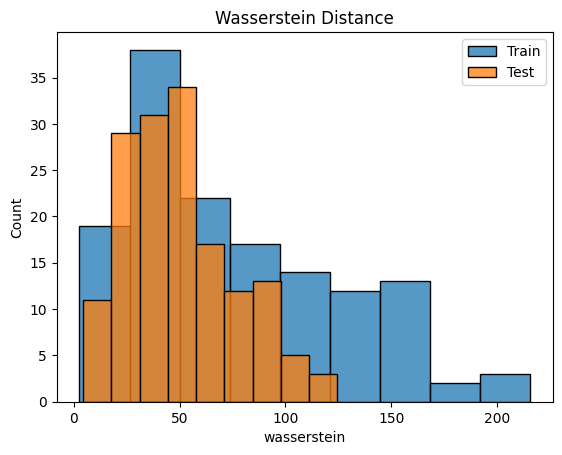

In [14]:
sns.histplot(w_train_df['wasserstein'], label='Train')
sns.histplot(w_test_df['wasserstein'], label='Test')
plt.legend()
plt.title('Wasserstein Distance')